In [1]:
## import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.rand(100, 1)

Text(0, 0.5, 'Y dataset')

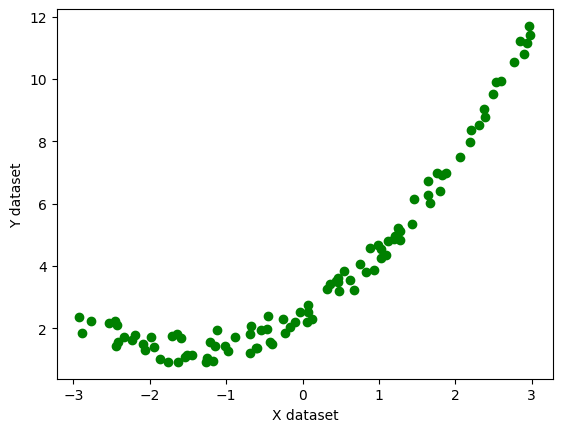

In [3]:
plt.scatter(X,y,color = 'g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_Test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

In [5]:
# Lets implement simple linear Regression

from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()


regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression_1.predict(X_Test))

print(score)

0.8202612794393191


Text(0, 0.5, 'Y')

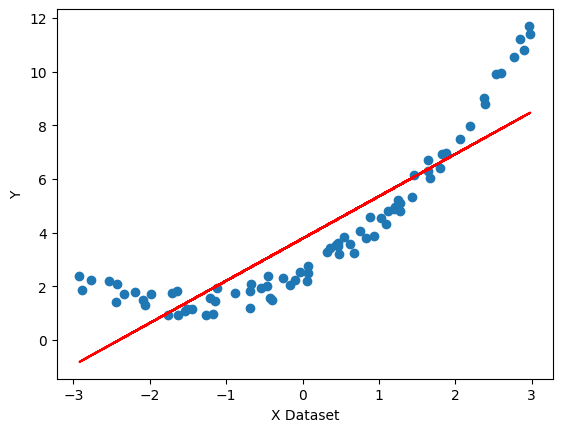

In [7]:
## Let's visualize this model

plt.plot(X_train,regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)

plt.xlabel("X Dataset")
plt.ylabel("Y")


In [8]:
# Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_Test_poly = poly.transform(X_Test)

In [10]:
X_train_poly

array([[ 1.00000000e+00, -2.06698919e+00,  4.27244429e+00],
       [ 1.00000000e+00,  9.39553529e-01,  8.82760835e-01],
       [ 1.00000000e+00,  1.27308466e+00,  1.62074455e+00],
       [ 1.00000000e+00, -1.51222682e+00,  2.28682995e+00],
       [ 1.00000000e+00, -2.44331212e+00,  5.96977411e+00],
       [ 1.00000000e+00,  1.80202116e+00,  3.24728028e+00],
       [ 1.00000000e+00, -2.34116567e+00,  5.48105669e+00],
       [ 1.00000000e+00, -8.85765150e-01,  7.84579901e-01],
       [ 1.00000000e+00,  2.98153269e+00,  8.88953717e+00],
       [ 1.00000000e+00,  1.19260054e+00,  1.42229604e+00],
       [ 1.00000000e+00,  1.82047176e+00,  3.31411742e+00],
       [ 1.00000000e+00, -2.54430038e-01,  6.47346441e-02],
       [ 1.00000000e+00, -4.61891535e-01,  2.13343791e-01],
       [ 1.00000000e+00, -1.11576806e+00,  1.24493836e+00],
       [ 1.00000000e+00,  6.42415731e-02,  4.12697972e-03],
       [ 1.00000000e+00, -6.72647392e-01,  4.52454514e-01],
       [ 1.00000000e+00,  1.09320420e+00

In [11]:
X_Test_poly

array([[ 1.        ,  2.20121157,  4.84533238],
       [ 1.        , -2.23801839,  5.00872631],
       [ 1.        ,  2.31247842,  5.34755643],
       [ 1.        ,  2.93445203,  8.61100874],
       [ 1.        ,  0.98719902,  0.9745619 ],
       [ 1.        , -1.2555782 ,  1.57647663],
       [ 1.        , -0.23397588,  0.05474471],
       [ 1.        , -1.01754557,  1.03539899],
       [ 1.        ,  2.48748094,  6.18756141],
       [ 1.        , -0.60682486,  0.36823641],
       [ 1.        ,  1.02321595,  1.04697087],
       [ 1.        ,  1.7570094 ,  3.08708204],
       [ 1.        , -1.59035204,  2.5292196 ],
       [ 1.        , -0.59178144,  0.35020528],
       [ 1.        , -2.45615327,  6.03268888],
       [ 1.        , -2.41606493,  5.83736975],
       [ 1.        ,  0.12351793,  0.01525668],
       [ 1.        , -1.8647373 ,  3.4772452 ],
       [ 1.        , -1.94506498,  3.78327777],
       [ 1.        , -0.97426065,  0.9491838 ]])

In [12]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_Test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.9932824409212844


In [13]:
print(regression.coef_)

[[0.         1.51325283 0.50621144]]


In [14]:
print(regression.intercept_)

[2.4592759]


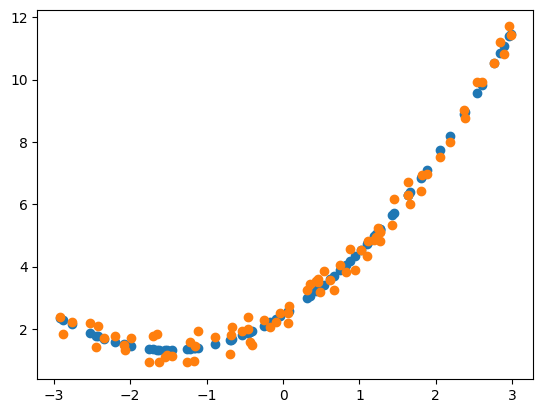

In [15]:
plt.scatter(X_train, regression.predict(X_train_poly))

plt.scatter(X_train,y_train)

In [16]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_Test_poly = poly.transform(X_Test)

In [17]:
X_train_poly

array([[ 1.00000000e+00, -2.06698919e+00,  4.27244429e+00,
        -8.83109615e+00],
       [ 1.00000000e+00,  9.39553529e-01,  8.82760835e-01,
         8.29401058e-01],
       [ 1.00000000e+00,  1.27308466e+00,  1.62074455e+00,
         2.06334501e+00],
       [ 1.00000000e+00, -1.51222682e+00,  2.28682995e+00,
        -3.45820558e+00],
       [ 1.00000000e+00, -2.44331212e+00,  5.96977411e+00,
        -1.45860214e+01],
       [ 1.00000000e+00,  1.80202116e+00,  3.24728028e+00,
         5.85166779e+00],
       [ 1.00000000e+00, -2.34116567e+00,  5.48105669e+00,
        -1.28320618e+01],
       [ 1.00000000e+00, -8.85765150e-01,  7.84579901e-01,
        -6.94953533e-01],
       [ 1.00000000e+00,  2.98153269e+00,  8.88953717e+00,
         2.65044457e+01],
       [ 1.00000000e+00,  1.19260054e+00,  1.42229604e+00,
         1.69623102e+00],
       [ 1.00000000e+00,  1.82047176e+00,  3.31411742e+00,
         6.03325716e+00],
       [ 1.00000000e+00, -2.54430038e-01,  6.47346441e-02,
      

In [18]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_Test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.9925763990314153


In [19]:
print(regression.coef_)


[[0.         1.47133625 0.50369444 0.00800984]]


In [20]:
print(regression.intercept_)


[2.46622559]


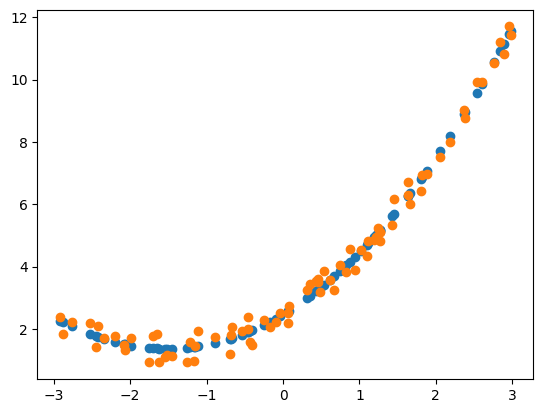

In [21]:
plt.scatter(X_train, regression.predict(X_train_poly))

plt.scatter(X_train,y_train)

In [23]:
# Prediction of a new dataset

X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

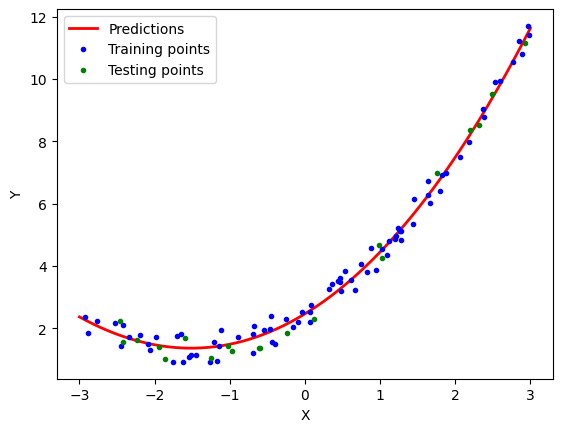

In [26]:
y_new = regression.predict(X_new_poly)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')

plt.plot(X_Test,y_test, "g." ,label='Testing points')

plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.show()



In [27]:
from sklearn.pipeline import Pipeline

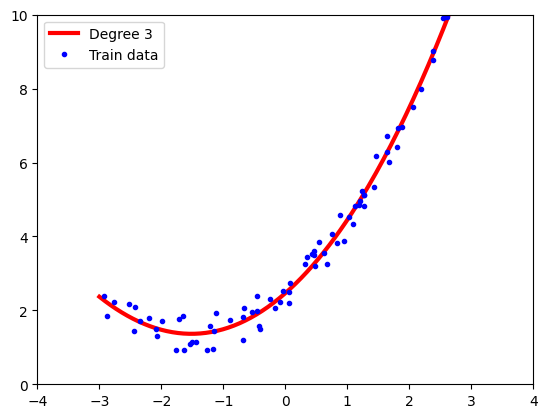

In [43]:
def get_poly_regression(degree):
    # 1. Define the components
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    line_reg = LinearRegression()
    
    # 2. Build the pipeline
    poly_pipeline = Pipeline([
            ("poly_features", poly_features),
            ("lin_reg", line_reg)
        ])
    
    # 3. CRITICAL: You must return the pipeline object
    return poly_pipeline

# 4. Call the function and store the returned object in a variable
degree_value = 3
model = get_poly_regression(degree_value)

# 5. Use the variable (the model), NOT the function name
model.fit(X_train, y_train)

X_new = np.linspace(-3, 3, 200).reshape(200, 1)
y_pred_new = model.predict(X_new)

# Plotting
plt.plot(X_new, y_pred_new, 'r', label="Degree " + str(degree_value), linewidth=3)
plt.plot(X_train, y_train, "b.", label="Train data")
plt.axis([-4, 4, 0, 10])
plt.legend()
plt.show()

In [44]:
get_poly_regression(2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly_features', ...), ('lin_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
